## Decision Tree Model

Import the necessary libraries

In [40]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report
from sklearn.compose import ColumnTransformer
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

Load the dataset

In [41]:
meps_data = pd.read_csv('Datasets/integrated_data.csv')
meps_data.head()

,Unnamed: 0,Person.ID,Drug,Quantity,Strength,Day_Supply,Daily_Frequency,Daily_Dosage,Year,Age,Sex,Ethnicity,Race,Personal_income,Family_income,Poverty_category,Can.t_get_PMED,Insurance_coverage,PMED_insurance_coverage,Concentration
0,1,40001101,desoximetasone,60.0,50000.0,30.000000,2.000000,100000.000000,2014,36.0,1.0,3.0,2.0,12000.0,68000.0,4.0,2.0,1.0,1.0,0.000805
1,2,40001101,desoximetasone,60.0,50000.0,30.000000,2.000000,100000.000000,2014,36.0,1.0,3.0,2.0,12000.0,68000.0,4.0,2.0,1.0,1.0,0.000805
2,3,41807102,desoximetasone,60.0,250000.0,25.777778,2.327586,581896.551724,2014,30.0,2.0,4.0,4.0,0.0,100000.0,5.0,2.0,1.0,1.0,0.004687
3,4,42214102,desoximetasone,100.0,250000.0,25.777778,3.879310,969827.586207,2014,61.0,2.0,2.0,1.0,66410.0,105604.0,5.0,2.0,2.0,2.0,0.007811
4,5,42214102,desoximetasone,100.0,250000.0,25.777778,3.879310,969827.586207,2014,61.0,2.0,2.0,1.0,66410.0,105604.0,5.0,2.0,2.0,2.0,0.007811


In [42]:
print(meps_data.columns)

Index(['Unnamed: 0', 'Person.ID', 'Drug', 'Quantity', 'Strength', 'Day_Supply',
       'Daily_Frequency', 'Daily_Dosage', 'Year', 'Age', 'Sex', 'Ethnicity',
       'Race', 'Personal_income', 'Family_income', 'Poverty_category',
       'Can.t_get_PMED', 'Insurance_coverage', 'PMED_insurance_coverage',
       'Concentration'],
      dtype='object')


In [17]:
# randomly sample rows from dataset to make model more manageable
meps_data = meps_data.sample(n=100000, random_state=42)

Handling infinite ranged values

In [18]:
meps_data = meps_data[~meps_data.isin([np.inf, -np.inf]).any(axis=1)]

Unwanted columns to drop

In [19]:
columns_to_drop = ['Unnamed: 0', 'Person.ID']
meps_data = meps_data.drop(columns=columns_to_drop, errors='ignore')
meps_data.head()

,Drug,Quantity,Strength,Day_Supply,Daily_Frequency,Daily_Dosage,Year,Age,Sex,Ethnicity,Race,Personal_income,Family_income,Poverty_category,Can.t_get_PMED,Insurance_coverage,PMED_insurance_coverage,Concentration
976881,amlodipine,45.0,5000.0,90.000000,0.500000,2500.000000,2022,71.0,1.0,2.0,1.0,16088.0,16088.0,2.0,2.0,6.0,2.0000,0.000020
277559,bupropion,180.0,75000.0,47.321643,3.803756,285281.724437,2018,33.0,2.0,2.0,1.0,14761.0,57661.0,3.0,2.0,1.0,1.1705,0.002298
195551,metoprolol,30.0,50000.0,54.055964,0.554980,27749.019422,2016,49.0,2.0,5.0,12.0,11820.0,11820.0,1.0,2.0,2.0,2.0000,0.000223
3033,montelukast,90.0,10000.0,90.000000,1.000000,10000.000000,2014,48.0,2.0,2.0,1.0,9376.0,9376.0,1.0,2.0,2.0,2.0000,0.000081
308363,atorvastatin,30.0,10000.0,61.008716,0.491733,4917.330213,2018,50.0,2.0,3.0,2.0,26040.0,50280.0,4.0,2.0,2.0,2.0000,0.000040


check missing values

In [20]:
missing_values = meps_data.isnull().sum()
print("Missing values in each column:")
print(missing_values[missing_values > 0])

Missing values in each column:
Strength                    1
Daily_Dosage                1
Age                        60
Sex                        60
Ethnicity                  60
Race                       60
Personal_income            60
Family_income              60
Poverty_category           60
Can.t_get_PMED             60
Insurance_coverage         60
PMED_insurance_coverage    60
Concentration               1
dtype: int64


Handle missing values

Fill numeric columns with mean and categorical columns with mode

In [21]:
meps_data = meps_data.fillna(meps_data.mean(numeric_only=True))  # Numeric columns
for col in meps_data.select_dtypes(include=['object']).columns:
    meps_data[col] = meps_data[col].fillna(meps_data[col].mode()[0])

In [23]:
missing_values = meps_data.isnull().sum()
print("Missing values in each column:")
print(missing_values[missing_values > 0])

Missing values in each column:
Series([], dtype: int64)


Drug column encoding

In [24]:
encoder = LabelEncoder()
meps_data['Drug'] = encoder.fit_transform(meps_data['Drug'])
meps_data.head()

,Drug,Quantity,Strength,Day_Supply,Daily_Frequency,Daily_Dosage,Year,Age,Sex,Ethnicity,Race,Personal_income,Family_income,Poverty_category,Can.t_get_PMED,Insurance_coverage,PMED_insurance_coverage,Concentration
976881,14,45.0,5000.0,90.000000,0.500000,2500.000000,2022,71.0,1.0,2.0,1.0,16088.0,16088.0,2.0,2.0,6.0,2.0000,0.000020
277559,49,180.0,75000.0,47.321643,3.803756,285281.724437,2018,33.0,2.0,2.0,1.0,14761.0,57661.0,3.0,2.0,1.0,1.1705,0.002298
195551,243,30.0,50000.0,54.055964,0.554980,27749.019422,2016,49.0,2.0,5.0,12.0,11820.0,11820.0,1.0,2.0,2.0,2.0000,0.000223
3033,252,90.0,10000.0,90.000000,1.000000,10000.000000,2014,48.0,2.0,2.0,1.0,9376.0,9376.0,1.0,2.0,2.0,2.0000,0.000081
308363,24,30.0,10000.0,61.008716,0.491733,4917.330213,2018,50.0,2.0,3.0,2.0,26040.0,50280.0,4.0,2.0,2.0,2.0000,0.000040


Model Implementation - stage 1 with raw data

In [25]:
X = meps_data.drop('Drug', axis=1)
y = meps_data['Drug']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set size: {X_train.shape}, Testing set size: {X_test.shape}")

clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")
print("Classification Report:")
print(classification_report(y_test, y_pred))

Training set size: (79996, 17), Testing set size: (20000, 17)
Accuracy: 0.63
Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.62      0.59        90
           2       1.00      1.00      1.00         1
           3       0.48      0.65      0.56        23
           4       0.00      0.00      0.00         0
           5       0.99      0.99      0.99       542
           6       0.97      0.97      0.97        63
           7       0.00      0.00      0.00         3
           8       0.57      0.61      0.59       115
           9       0.67      1.00      0.80         2
          10       0.77      0.75      0.76       165
          11       0.00      0.00      0.00         0
          12       0.44      0.57      0.50        14
          13       0.32      0.33      0.32        64
          14       0.58      0.58      0.58       664
          15       1.00      1.00      1.00         5
          16       0.81      0.74  

/Users/akhilaannireddy/Projects/sewer_project/sewerenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/akhilaannireddy/Projects/sewer_project/sewerenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/akhilaannireddy/Projects/sewer_project/sewerenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior

Feature Importances:
 Strength                   0.207797
Day_Supply                 0.145158
Age                        0.110868
Family_income              0.097589
Personal_income            0.095679
Year                       0.070004
Quantity                   0.055319
Daily_Frequency            0.038627
Concentration              0.032589
Insurance_coverage         0.026767
Daily_Dosage               0.026220
Ethnicity                  0.021936
Poverty_category           0.018463
PMED_insurance_coverage    0.017274
Sex                        0.015884
Race                       0.013655
Can.t_get_PMED             0.006172
dtype: float64


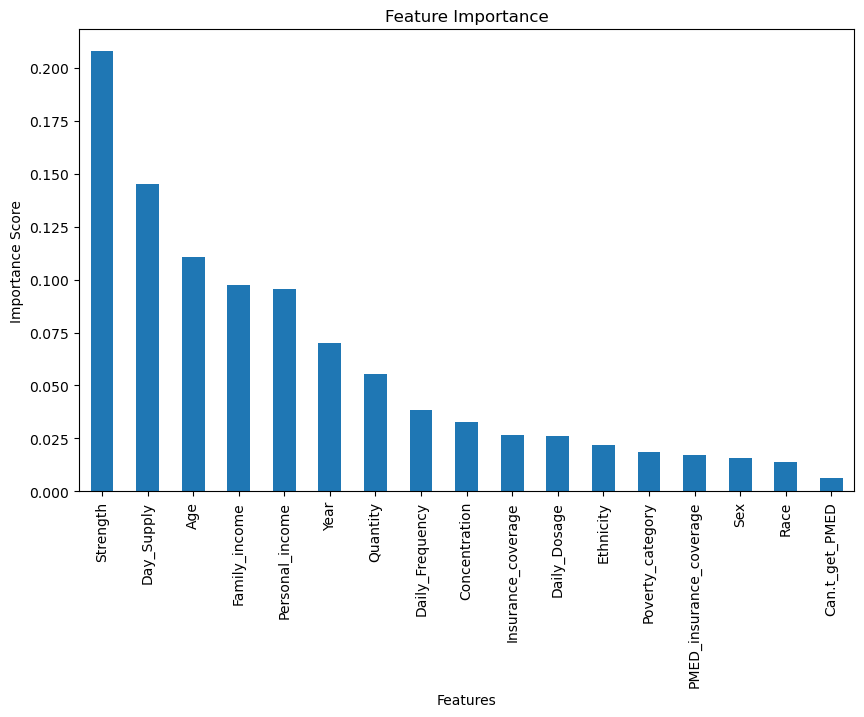

In [26]:
feature_importances = pd.Series(clf.feature_importances_, index=X.columns)
feature_importances.sort_values(ascending=False, inplace=True)
print("Feature Importances:\n", feature_importances)

plt.figure(figsize=(10, 6))
feature_importances.plot(kind='bar')
plt.title('Feature Importance')
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.show()

checking for duplicate records

In [126]:
duplicates = meps_data.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")
meps_data = meps_data.drop_duplicates()

Number of duplicate rows: 720711


Model implementation - 2 with no duplicate records

In [127]:
X = meps_data.drop('Drug', axis=1)
y = meps_data['Drug']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set size: {X_train.shape}, Testing set size: {X_test.shape}")

clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")
print("Classification Report:")
print(classification_report(y_test, y_pred))

Training set size: (268278, 17), Testing set size: (67070, 17)
Accuracy: 0.58
Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.71      0.72       423
           1       0.33      0.20      0.25         5
           2       1.00      1.00      1.00         1
           3       0.55      0.56      0.56       112
           4       0.38      0.50      0.43         6
           5       0.99      0.99      0.99      2170
           6       0.98      0.99      0.98       207
           7       0.14      0.14      0.14        14
           8       0.48      0.49      0.49       381
           9       0.12      0.14      0.13         7
          10       0.62      0.63      0.62       421
          11       0.50      0.33      0.40         3
          12       0.50      0.39      0.44        85
          13       0.23      0.31      0.27       172
          14       0.48      0.50      0.49      1839
          15       1.00      1.00 

/Users/akhilaannireddy/Projects/sewer_project/sewerenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/akhilaannireddy/Projects/sewer_project/sewerenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/akhilaannireddy/Projects/sewer_project/sewerenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior

Feature Importances:
 Strength                   0.207797
Day_Supply                 0.145158
Age                        0.110868
Family_income              0.097589
Personal_income            0.095679
Year                       0.070004
Quantity                   0.055319
Daily_Frequency            0.038627
Concentration              0.032589
Insurance_coverage         0.026767
Daily_Dosage               0.026220
Ethnicity                  0.021936
Poverty_category           0.018463
PMED_insurance_coverage    0.017274
Sex                        0.015884
Race                       0.013655
Can.t_get_PMED             0.006172
dtype: float64


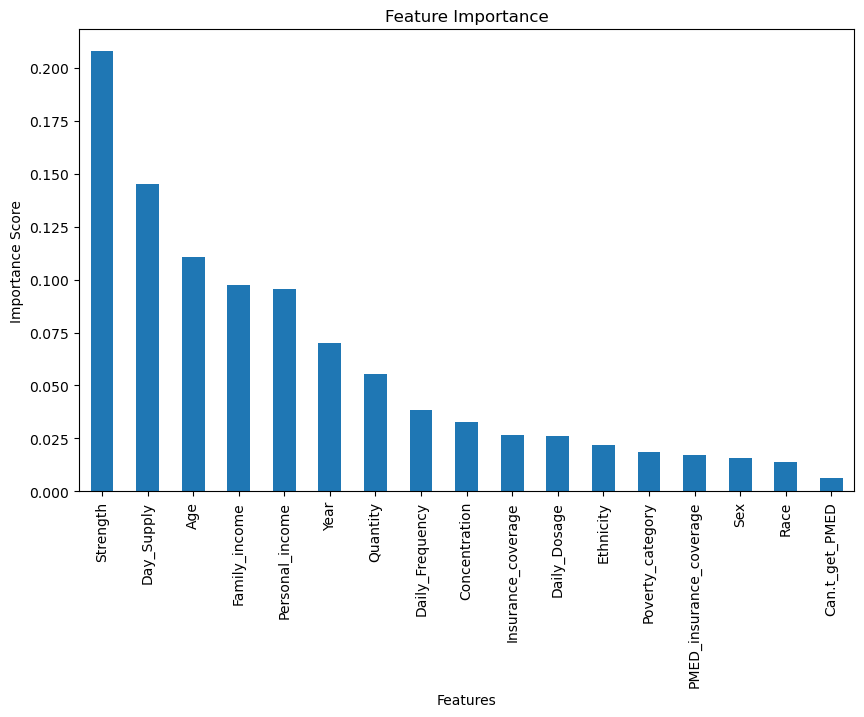

In [27]:
feature_importances = pd.Series(clf.feature_importances_, index=X.columns)
feature_importances.sort_values(ascending=False, inplace=True)
print("Feature Importances:\n", feature_importances)

plt.figure(figsize=(10, 6))
feature_importances.plot(kind='bar')
plt.title('Feature Importance')
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.show()

Checking corelation between features

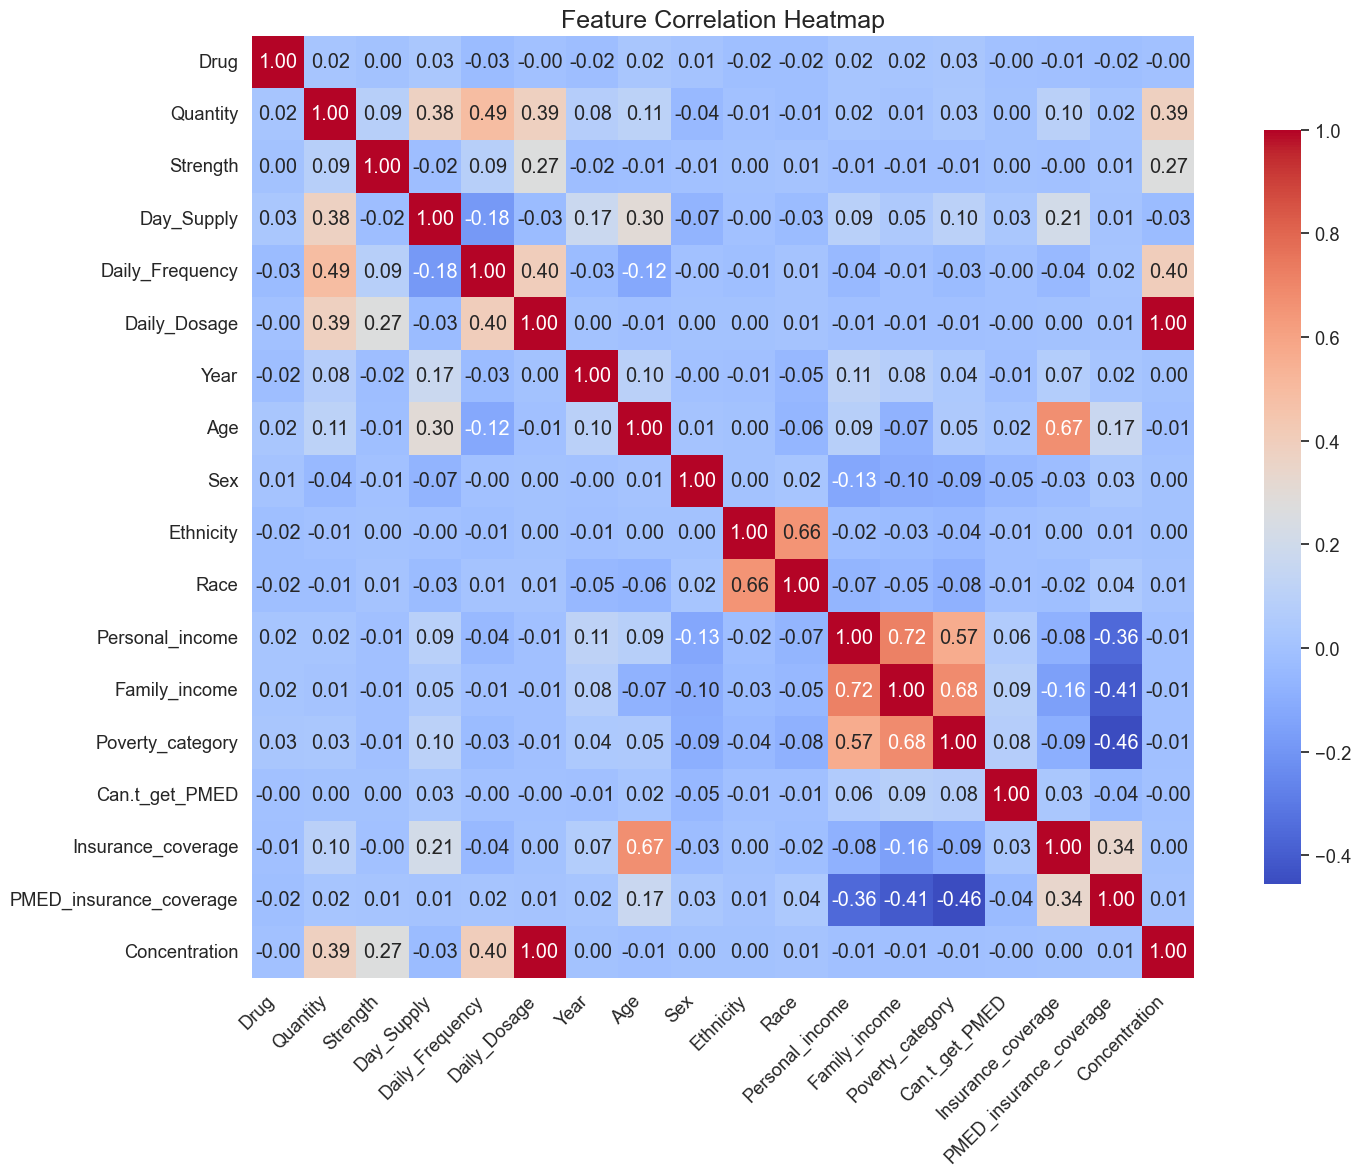

In [28]:
correlation_matrix = meps_data.corr()

plt.figure(figsize=(16, 12)) 
sns.set(font_scale=1.2)  
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    cbar_kws={'shrink': 0.8},
    square=True
)

plt.title('Feature Correlation Heatmap', fontsize=18)
plt.xticks(rotation=45, ha='right')
plt.tight_layout() 
plt.show()


Based on the above corelation graph, dropping higly corelated columns 

In [29]:
columns_to_drop = [
    'Personal_income',       # Highly correlated with Family_income
    'Poverty_category',      # Redundant with Family_income
    'Daily_Frequency',       # Correlated with Day_Supply
]
meps_data = meps_data.drop(columns=columns_to_drop)
print("Remaining columns after dropping:", meps_data.columns)

Remaining columns after dropping: Index(['Drug', 'Quantity', 'Strength', 'Day_Supply', 'Daily_Dosage', 'Year',
       'Age', 'Sex', 'Ethnicity', 'Race', 'Family_income', 'Can.t_get_PMED',
       'Insurance_coverage', 'PMED_insurance_coverage', 'Concentration'],
      dtype='object')


Model implementation - 3 after dropping columns that are highly corelated

In [30]:
X = meps_data.drop('Drug', axis=1)
y = meps_data['Drug']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set size: {X_train.shape}, Testing set size: {X_test.shape}")

clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")
print("Classification Report:")
print(classification_report(y_test, y_pred))

Training set size: (79996, 14), Testing set size: (20000, 14)
Accuracy: 0.64
Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.60      0.59        90
           2       1.00      1.00      1.00         1
           3       0.50      0.70      0.58        23
           4       0.00      0.00      0.00         0
           5       0.99      0.99      0.99       542
           6       0.94      1.00      0.97        63
           7       0.00      0.00      0.00         3
           8       0.56      0.62      0.59       115
           9       0.50      1.00      0.67         2
          10       0.79      0.73      0.76       165
          11       0.00      0.00      0.00         0
          12       0.41      0.64      0.50        14
          13       0.34      0.34      0.34        64
          14       0.61      0.58      0.59       664
          15       1.00      1.00      1.00         5
          16       0.78      0.77  

/Users/akhilaannireddy/Projects/sewer_project/sewerenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/akhilaannireddy/Projects/sewer_project/sewerenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/akhilaannireddy/Projects/sewer_project/sewerenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior

In [96]:
print(meps_data.columns)

Index(['Drug', 'Quantity', 'Strength', 'Day_Supply', 'Daily_Dosage', 'Year',
       'Age', 'Sex', 'Ethnicity', 'Race', 'Family_income', 'Can.t_get_PMED',
       'Insurance_coverage', 'PMED_insurance_coverage', 'Concentration'],
      dtype='object')


In [31]:
param_grid = {
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}
grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)
print("Best parameters found:", grid_search.best_params_)
best_model = grid_search.best_estimator_


/Users/akhilaannireddy/Projects/sewer_project/sewerenv/lib/python3.12/site-packages/sklearn/model_selection/_split.py:776: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Best parameters found: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}


Model implementation - 4 after hyper param tuning using grid search cv

In [32]:
clf = DecisionTreeClassifier(
    criterion='gini',
    max_depth=20,
    min_samples_leaf=1,
    min_samples_split=2,
    random_state=42
)
clf.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=20, random_state=42)

In [33]:
y_pred = clf.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("Classification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 0.57
Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.58      0.59        90
           2       1.00      1.00      1.00         1
           3       0.45      0.57      0.50        23
           5       0.99      0.99      0.99       542
           6       0.94      1.00      0.97        63
           7       0.00      0.00      0.00         3
           8       0.56      0.50      0.53       115
           9       0.67      1.00      0.80         2
          10       0.68      0.61      0.64       165
          11       0.00      0.00      0.00         0
          12       0.11      0.29      0.15        14
          13       0.26      0.12      0.17        64
          14       0.35      0.86      0.49       664
          15       1.00      1.00      1.00         5
          16       0.81      0.77      0.79       170
          17       0.00      0.00      0.00         2
          18       0.52      0.64      0.57

/Users/akhilaannireddy/Projects/sewer_project/sewerenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/akhilaannireddy/Projects/sewer_project/sewerenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/akhilaannireddy/Projects/sewer_project/sewerenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior

Applying feature importance

Feature Importances:
 Strength                   0.209717
Family_income              0.155556
Day_Supply                 0.152303
Age                        0.129374
Year                       0.080658
Quantity                   0.063755
Daily_Dosage               0.048103
Concentration              0.038407
Insurance_coverage         0.031693
Ethnicity                  0.024745
PMED_insurance_coverage    0.022459
Sex                        0.019231
Race                       0.015847
Can.t_get_PMED             0.008152
dtype: float64


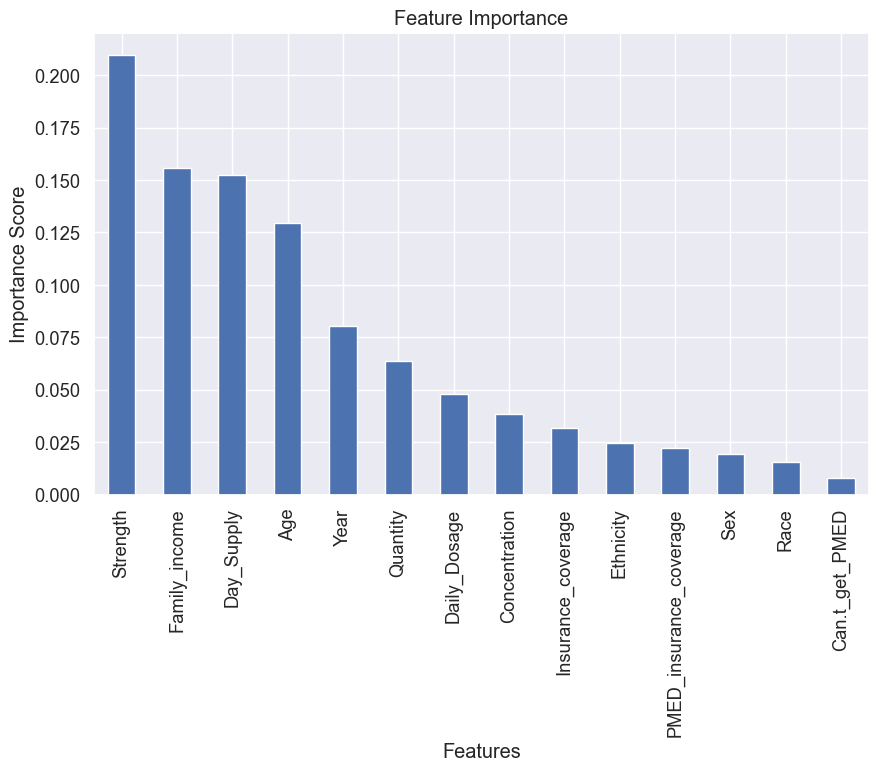

In [34]:
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

feature_importances = pd.Series(clf.feature_importances_, index=X.columns)
feature_importances.sort_values(ascending=False, inplace=True)
print("Feature Importances:\n", feature_importances)

plt.figure(figsize=(10, 6))
feature_importances.plot(kind='bar')
plt.title('Feature Importance')
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.show()

droping unimportant columns

In [35]:
columns_to_drop = ['Can.t_get_PMED', 'Race', 'Sex', 'PMED_insurance_coverage']
X_train_reduced = X_train.drop(columns=columns_to_drop)
X_test_reduced = X_test.drop(columns=columns_to_drop)
print("Remaining columns after dropping:", X_train_reduced.columns)

Remaining columns after dropping: Index(['Quantity', 'Strength', 'Day_Supply', 'Daily_Dosage', 'Year', 'Age',
       'Ethnicity', 'Family_income', 'Insurance_coverage', 'Concentration'],
      dtype='object')


In [36]:
clf.fit(X_train_reduced, y_train)
y_pred_reduced = clf.predict(X_test_reduced)

print(f"Accuracy with reduced features: {accuracy_score(y_test, y_pred_reduced):.2f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_reduced))

Accuracy with reduced features: 0.64
Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.60      0.61        90
           2       1.00      1.00      1.00         1
           3       0.47      0.65      0.55        23
           5       0.99      0.99      0.99       542
           6       0.94      0.97      0.95        63
           7       0.00      0.00      0.00         3
           8       0.52      0.57      0.55       115
           9       0.50      0.50      0.50         2
          10       0.77      0.74      0.75       165
          11       0.00      0.00      0.00         0
          12       0.31      0.57      0.40        14
          13       0.30      0.33      0.31        64
          14       0.61      0.57      0.59       664
          15       1.00      1.00      1.00         5
          16       0.79      0.74      0.76       170
          17       0.00      0.00      0.00         2
          18       0.

/Users/akhilaannireddy/Projects/sewer_project/sewerenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/akhilaannireddy/Projects/sewer_project/sewerenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/akhilaannireddy/Projects/sewer_project/sewerenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior

Basic cross validation

In [131]:
clf = DecisionTreeClassifier(random_state=42)
scores = cross_val_score(clf, X, y, cv=5, scoring='accuracy')
print(f"Cross-validation scores: {scores}")
print(f"Mean accuracy: {scores.mean():.2f}")

/Users/akhilaannireddy/Projects/sewer_project/sewerenv/lib/python3.12/site-packages/sklearn/model_selection/_split.py:776: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Cross-validation scores: [0.36121962 0.46927091 0.54540033 0.56177966 0.45432316]
Mean accuracy: 0.48


Cross-Validation with Stratification

In [133]:
clf = DecisionTreeClassifier(random_state=42)
stratified_kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(clf, X, y, cv=stratified_kf, scoring='accuracy')
print(f"Stratified cross-validation scores: {scores}")
print(f"Mean accuracy: {scores.mean():.2f}")

/Users/akhilaannireddy/Projects/sewer_project/sewerenv/lib/python3.12/site-packages/sklearn/model_selection/_split.py:776: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Stratified cross-validation scores: [0.57963322 0.57979723 0.58039362 0.58026808 0.58201255]
Mean accuracy: 0.58


Summary :

1. Model accuracy with all the columns (person id, unnamed)- 0.91
2. removed duplicates - 0.58
3. checked corelation between features and dropped higly corelated ones - 0.58
4. applied hyper param tuning - 0.60
5. applied feature importnace and dropped unimportant features - 0.58
6. basic cross validation - 0.48 avg
7. cross validation with stratifiedkfold - 0.58 avg